In [ ]:
import sys
import re
from pathlib import Path

CODE_DIR = (Path.cwd().parent).resolve()
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from cloudprompts.evaluation import evaluate_segmentation


In [ ]:
from pathlib import Path

VARIANT_ROOT = Path("../inference/clipseg_cloudsen12plus_prompt_variants").expanduser().resolve()

VARIANT_GLOB = "**/V*"

GT_DIR = Path("../data/cloudsen12plus/export_p509_high_npz/test/masks").expanduser().resolve()

OUT_DIR = (Path.cwd().resolve() / "variant_eval").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL = "clipseg"
DATASET = "cloudsen12plus"

NUM_CLASSES = 4
CLASS_NAMES = ["clear", "thick_cloud", "thin_cloud", "cloud_shadow"]

GT_KEY = "mask"
PRED_KEY = "mask"
GT_EXT = ".npz"
PRED_EXT = ".npz"

IGNORE_INDEX = None
STRICT = True

print("VARIANT_ROOT:", VARIANT_ROOT, "exists:", VARIANT_ROOT.exists())
print("GT_DIR      :", GT_DIR, "exists:", GT_DIR.exists())
print("OUT_DIR     :", OUT_DIR, "exists:", OUT_DIR.exists())


THICK_CLOUD_VARIANTS = [
  "white cloud",
  "bright white cloud",
  "white opaque cloud",
  "bright cloud",
  "opaque cloud",
  "white",
  "cloud",
  "overhead cloud",
  "bright white",
  "thick cloud",
  "white dense cloud",
  "cloud overhead",
  "bright opaque cloud",
  "white solid cloud",
  "brightest cloud",
]

THIN_CLOUD_VARIANTS = [
  "thin cloud",
  "wispy cloud",
  "cloud layer",
  "translucent cloud",
  "semi-transparent cloud",
  "cloud with ground visible",
  "faded cloud",
  "soft cloud",
  "hazy cloud",
  "light cloud",
  "cloud veil",
  "partial cloud",
  "delicate cloud",
  "subtle cloud",
  "cloud layer with texture",
]

CLEAR_VARIANTS = [
  "ground",
  "earth",
  "surface",
  "land",
  "terrain",
  "colored ground",
  "ground below",
  "visible ground",
  "earth surface",
  "open ground",
  "clear ground",
  "ground below sky",
  "landscape",
  "exposed ground",
  "bright ground",
]

SHADOW_VARIANTS = [
  "shadow",
  "dark shadow",
  "shadow on ground",
  "shadow below",
  "dark area",
  "shade",
  "dark patch",
  "sharp shadow",
  "shadow with edges",
  "ground shadow",
  "cloud shadow",
  "dark region",
  "shadow beneath cloud",
  "darkest area",
  "shadow line",
]

assert len(THICK_CLOUD_VARIANTS) == len(THIN_CLOUD_VARIANTS) == len(CLEAR_VARIANTS) == len(SHADOW_VARIANTS) == 15

VARIANT_PROMPTS = []
for i in range(15):
    VARIANT_PROMPTS.append({
        "variant": f"V{i+1}",
        "clear": CLEAR_VARIANTS[i],
        "thick_cloud": THICK_CLOUD_VARIANTS[i],
        "thin_cloud": THIN_CLOUD_VARIANTS[i],
        "cloud_shadow": SHADOW_VARIANTS[i],
    })

for row in VARIANT_PROMPTS[:3]:
    print(row)
print("... total variants:", len(VARIANT_PROMPTS))


VARIANT_ROOT: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants exists: True
GT_DIR      : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/data/cloudsen12plus/export_p509_high_npz/test/masks exists: True
OUT_DIR     : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/variant_eval exists: True
{'variant': 'V1', 'clear': 'ground', 'thick_cloud': 'white cloud', 'thin_cloud': 'thin cloud', 'cloud_shadow': 'shadow'}
{'variant': 'V2', 'clear': 'earth', 'thick_cloud': 'bright white cloud', 'thin_cloud': 'wispy cloud', 'cloud_shadow': 'dark shadow'}
{'variant': 'V3', 'clear': 'surface', 'thick_cloud': 'white opaque cloud', 'thin_cloud': 'cloud layer', 'cloud_shadow': 'shadow on ground'}
... total v

In [ ]:
from pathlib import Path
import re

def discover_variant_dirs():
    dirs = [p.resolve() for p in VARIANT_ROOT.glob(VARIANT_GLOB) if p.is_dir()]
    keep = []
    for d in dirs:
        m = re.match(r"^V(\d+)$", d.name)
        if not m:
            continue
        v = int(m.group(1))
        if 1 <= v <= 15:
            keep.append(d)

    keep.sort(key=lambda p: int(re.match(r"^V(\d+)$", p.name).group(1)))
    return keep

VARIANT_DIRS_FOUND = discover_variant_dirs()

print("Found variant dirs:")
for d in VARIANT_DIRS_FOUND:
    print(" -", d)


Found variant dirs:
 - /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V1
 - /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V2
 - /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V3
 - /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V4
 - /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V5
 - /Users/harshithkethavath/Library/Mobile Documents/co

In [ ]:
from pathlib import Path
import re

def sanitize_stage(s: str) -> str:
    s = s.strip()
    s = re.sub(r"[^A-Za-z0-9_\-]+", "_", s)
    return s

def extract_variant_tag(variant_dir: Path) -> str:
    m = re.match(r"^(V\d+)$", variant_dir.name)
    if m:
        return m.group(1)
    m = re.search(r"[\\/](V\d+)[\\/]", str(variant_dir))
    if m:
        return m.group(1)
    return variant_dir.name

def pick_latest_checkpoint(run_dir: Path) -> Path | None:
    ckpts = list(run_dir.glob("checkpoint-*"))
    if not ckpts:
        return None
    def step(p: Path) -> int:
        m = re.search(r"checkpoint-(\d+)", p.name)
        return int(m.group(1)) if m else -1
    ckpts.sort(key=step)
    return ckpts[-1]

def resolve_pred_dir(run_dir: Path) -> Path:
    if (run_dir / "masks").is_dir():
        return run_dir / "masks"

    ckpt = pick_latest_checkpoint(run_dir)
    if ckpt and (ckpt / "masks").is_dir():
        return ckpt / "masks"

    if list(run_dir.glob(f"*{PRED_EXT}")):
        return run_dir

    candidates = [p for p in run_dir.rglob("masks") if p.is_dir()]
    if candidates:
        candidates.sort(key=lambda p: len(list(p.glob(f"*{PRED_EXT}"))))
        return candidates[-1]

    raise FileNotFoundError(f"Could not find prediction masks under: {run_dir}")

def safe_rename(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        dst.unlink()
    src.rename(dst)


In [ ]:
results = []

for vdir in VARIANT_DIRS_FOUND:
    tag = extract_variant_tag(vdir)
    stage = sanitize_stage(tag)
    pred_dir = resolve_pred_dir(vdir)

    print(f"\n[INFO] Variant: {tag}")
    print("  variant_dir:", vdir)
    print("  pred_dir   :", pred_dir)
    print("  out_dir    :", OUT_DIR)
    print("  stage      :", stage)

    out = evaluate_segmentation(
        gt_dir=GT_DIR,
        pred_dir=pred_dir,
        model=MODEL,
        dataset=DATASET,
        stage=stage,
        num_classes=NUM_CLASSES,
        class_names=CLASS_NAMES,
        run_root=OUT_DIR,
        gt_key=GT_KEY,
        pred_key=PRED_KEY,
        gt_ext=GT_EXT,
        pred_ext=PRED_EXT,
        ignore_index=IGNORE_INDEX,
        strict=STRICT,
    )

    cm_src = Path(out["cm_csv"])
    miou_src = Path(out["miou_csv"])

    cm_dst = OUT_DIR / f"{tag}_cm.csv"
    iou_dst = OUT_DIR / f"{tag}_iou.csv"

    safe_rename(cm_src, cm_dst)
    safe_rename(miou_src, iou_dst)

    results.append({
        "variant": tag,
        "variant_dir": str(vdir),
        "pred_dir": str(pred_dir),
        "cm_csv": str(cm_dst),
        "iou_csv": str(iou_dst),
        "aggregate_miou": out.get("aggregate_miou"),
        "aggregate_pixel_acc": out.get("aggregate_pixel_acc"),
    })

results



[INFO] Variant: V1
  variant_dir: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V1
  pred_dir   : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V1/masks
  out_dir    : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/variant_eval
  stage      : V1


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)



[INFO] Variant: V2
  variant_dir: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V2
  pred_dir   : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V2/masks
  out_dir    : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/variant_eval
  stage      : V2


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)



[INFO] Variant: V3
  variant_dir: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V3
  pred_dir   : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V3/masks
  out_dir    : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/variant_eval
  stage      : V3


...


[INFO] Variant: V14
  variant_dir: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V14
  pred_dir   : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V14/masks
  out_dir    : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/variant_eval
  stage      : V14


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)



[INFO] Variant: V15
  variant_dir: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V15
  pred_dir   : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V15/masks
  out_dir    : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/variant_eval
  stage      : V15


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


[{'variant': 'V1',
  'variant_dir': '/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V1',
  'pred_dir': '/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_variants/V1/masks',
  'cm_csv': '/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/variant_eval/V1_cm.csv',
  'iou_csv': '/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/variant_eval/V1_iou.csv',
  'aggregate_miou': 0.22203864821525218,
  'aggregate_pixel_acc': 0.38243426591922075},
 {'variant': 'V2',
  'variant_dir': '/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia

In [ ]:

from pathlib import Path
import pandas as pd

def get_agg_row(df: pd.DataFrame, csv_path: Path) -> pd.Series:
    if "id" not in df.columns:
        raise ValueError(f"'id' column missing in {csv_path}")
    agg = df[df["id"] == "__aggregate__"]
    if agg.empty:
        raise ValueError(f"No __aggregate__ row found in {csv_path}")
    return agg.iloc[0]

variant_prompt_map = {row["variant"]: row for row in VARIANT_PROMPTS}

rows = []
for r in results:
    tag = r["variant"]
    p = Path(r["iou_csv"])
    df = pd.read_csv(p)
    agg = get_agg_row(df, p)
    prm = variant_prompt_map.get(tag, {})

    rows.append({
        "variant": tag,
        "miou": float(agg["miou"]),
        "iou_clear": float(agg["iou_clear"]),
        "iou_thick_cloud": float(agg["iou_thick_cloud"]),
        "iou_thin_cloud": float(agg["iou_thin_cloud"]),
        "iou_cloud_shadow": float(agg["iou_cloud_shadow"]),
        "prompt_clear": prm.get("clear"),
        "prompt_thick_cloud": prm.get("thick_cloud"),
        "prompt_thin_cloud": prm.get("thin_cloud"),
        "prompt_cloud_shadow": prm.get("cloud_shadow"),
    })

variant_df = pd.DataFrame(rows)

variant_df["vnum"] = variant_df["variant"].str.extract(r"V(\d+)").astype(int)
variant_df = variant_df.sort_values("vnum").drop(columns=["vnum"]).reset_index(drop=True)

display(variant_df)


,variant,miou,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow,prompt_clear,prompt_thick_cloud,prompt_thin_cloud,prompt_cloud_shadow
0,V1,0.222039,0.361088,0.308159,0.083555,0.135353,ground,white cloud,thin cloud,shadow
1,V2,0.196456,0.291248,0.345006,0.022516,0.127055,earth,bright white cloud,wispy cloud,dark shadow
2,V3,0.165606,0.223484,0.289099,0.090741,0.059100,surface,white opaque cloud,cloud layer,shadow on ground
3,V4,0.164304,0.347268,0.138881,0.091394,0.079675,land,bright cloud,translucent cloud,shadow below
4,V5,0.187621,0.277354,0.293561,0.079286,0.100283,terrain,opaque cloud,semi-transparent cloud,dark area
5,V6,0.165336,0.268412,0.254362,0.026659,0.111909,colored ground,white,cloud with ground visible,shade
6,V7,0.067676,0.057729,0.068061,0.078974,0.065940,ground below,cloud,faded cloud,dark patch
7,V8,0.216400,0.502066,0.168840,0.072285,0.122407,visible ground,overhead cloud,soft cloud,sharp shadow
8,V9,0.165080,0.402239,0.102546,0.096379,0.059158,earth surface,bright white,hazy cloud,shadow with edges
9,V10,0.107816,0.158710,0.144901,0.078622,0.049031,open ground,thick cloud,light cloud,ground shadow


In [ ]:

from pathlib import Path
import pandas as pd

ZS_MIOU_CSV = Path("../inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv").expanduser().resolve()
print("ZS_MIOU_CSV:", ZS_MIOU_CSV, "exists:", ZS_MIOU_CSV.exists())

zs_df = pd.read_csv(ZS_MIOU_CSV)
zs_agg = get_agg_row(zs_df, ZS_MIOU_CSV)

zs_vals = {
    "miou": float(zs_agg["miou"]),
    "iou_clear": float(zs_agg["iou_clear"]),
    "iou_thick_cloud": float(zs_agg["iou_thick_cloud"]),
    "iou_thin_cloud": float(zs_agg["iou_thin_cloud"]),
    "iou_cloud_shadow": float(zs_agg["iou_cloud_shadow"]),
}

zs_vals


ZS_MIOU_CSV: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv exists: True


{'miou': 0.2550400406013244,
 'iou_clear': 0.520532380887666,
 'iou_thick_cloud': 0.277302215426787,
 'iou_thin_cloud': 0.0898395431914562,
 'iou_cloud_shadow': 0.1324860228993884}

In [ ]:

import numpy as np

def pct_gain(x: float, base: float) -> float:
    return np.nan if base == 0 else (x - base) / base * 100.0

for metric in ["miou", "iou_clear", "iou_thick_cloud", "iou_thin_cloud", "iou_cloud_shadow"]:
    variant_df[f"{metric}_gain_abs"] = variant_df[metric] - zs_vals[metric]
    variant_df[f"{metric}_gain_pct"] = variant_df[metric].apply(lambda v: pct_gain(v, zs_vals[metric]))

cols = ["variant", "miou", "miou_gain_abs", "miou_gain_pct",
        "iou_clear_gain_pct", "iou_thick_cloud_gain_pct", "iou_thin_cloud_gain_pct", "iou_cloud_shadow_gain_pct",
        "prompt_clear", "prompt_thick_cloud", "prompt_thin_cloud", "prompt_cloud_shadow"]
display(variant_df[cols])


,variant,miou,miou_gain_abs,miou_gain_pct,iou_clear_gain_pct,iou_thick_cloud_gain_pct,iou_thin_cloud_gain_pct,iou_cloud_shadow_gain_pct,prompt_clear,prompt_thick_cloud,prompt_thin_cloud,prompt_cloud_shadow
0,V1,0.222039,-0.033001,-12.939691,-30.630993,11.127411,-6.995378,2.163797,ground,white cloud,thin cloud,shadow
1,V2,0.196456,-0.058584,-22.970399,-44.048029,24.415065,-74.937502,-4.099009,earth,bright white cloud,wispy cloud,dark shadow
2,V3,0.165606,-0.089434,-35.066662,-57.066239,4.254061,1.003136,-55.391267,surface,white opaque cloud,cloud layer,shadow on ground
3,V4,0.164304,-0.090736,-35.576984,-33.285950,-49.916976,1.730051,-39.861912,land,bright cloud,translucent cloud,shadow below
4,V5,0.187621,-0.067419,-26.434727,-46.717247,5.863253,-11.747189,-24.307067,terrain,opaque cloud,semi-transparent cloud,dark area
5,V6,0.165336,-0.089704,-35.172683,-48.435172,-8.272567,-70.325758,-15.531146,colored ground,white,cloud with ground visible,shade
6,V7,0.067676,-0.187364,-73.464614,-88.909659,-75.456119,-12.094204,-50.228918,ground below,cloud,faded cloud,dark patch
7,V8,0.216400,-0.038640,-15.150733,-3.547635,-39.113424,-19.539417,-7.607321,visible ground,overhead cloud,soft cloud,sharp shadow
8,V9,0.165080,-0.089960,-35.272747,-22.725542,-63.020115,7.278942,-55.347649,earth surface,bright white,hazy cloud,shadow with edges
9,V10,0.107816,-0.147224,-57.725759,-69.510052,-47.746000,-12.485872,-62.991472,open ground,thick cloud,light cloud,ground shadow


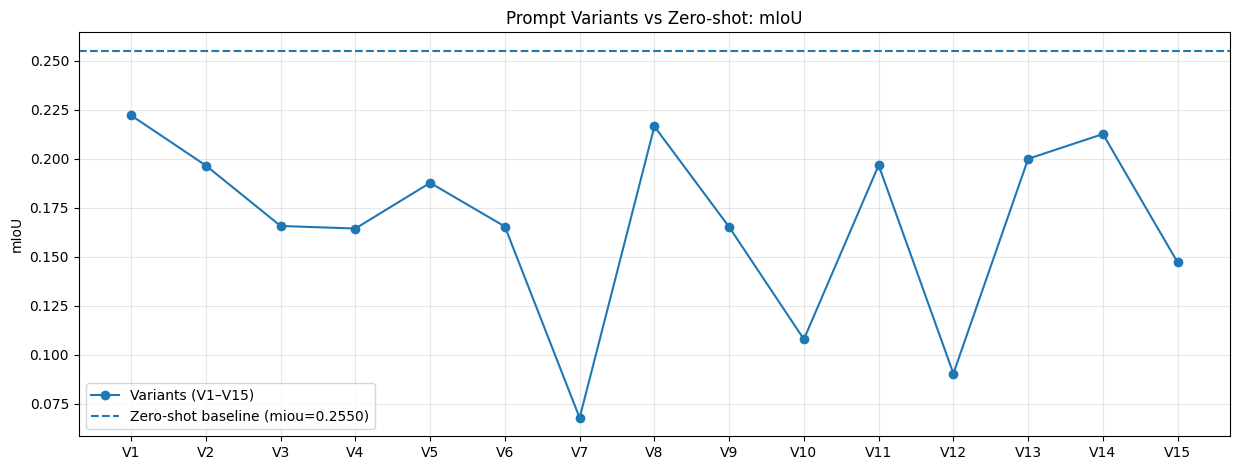

In [ ]:
import matplotlib.pyplot as plt

def plot_variants_vs_zs(metric: str, title: str, ylabel: str):
    x_labels = variant_df["variant"].tolist()
    y = variant_df[metric].astype(float).tolist()
    z = zs_vals[metric]

    plt.figure(figsize=(12.5, 4.8))
    plt.plot(range(len(x_labels)), y, marker="o", linestyle="-", label="Variants (V1–V15)")
    plt.axhline(z, linestyle="--", label=f"Zero-shot baseline ({metric}={z:.4f})")
    plt.xticks(range(len(x_labels)), x_labels, rotation=0)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_variants_vs_zs("miou", "Prompt Variants vs Zero-shot: mIoU", "mIoU")


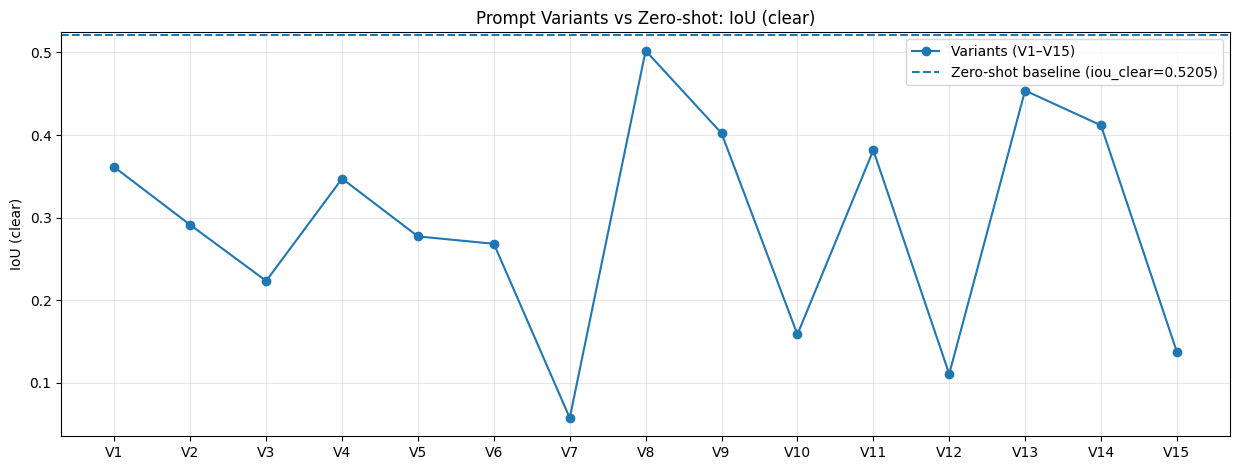

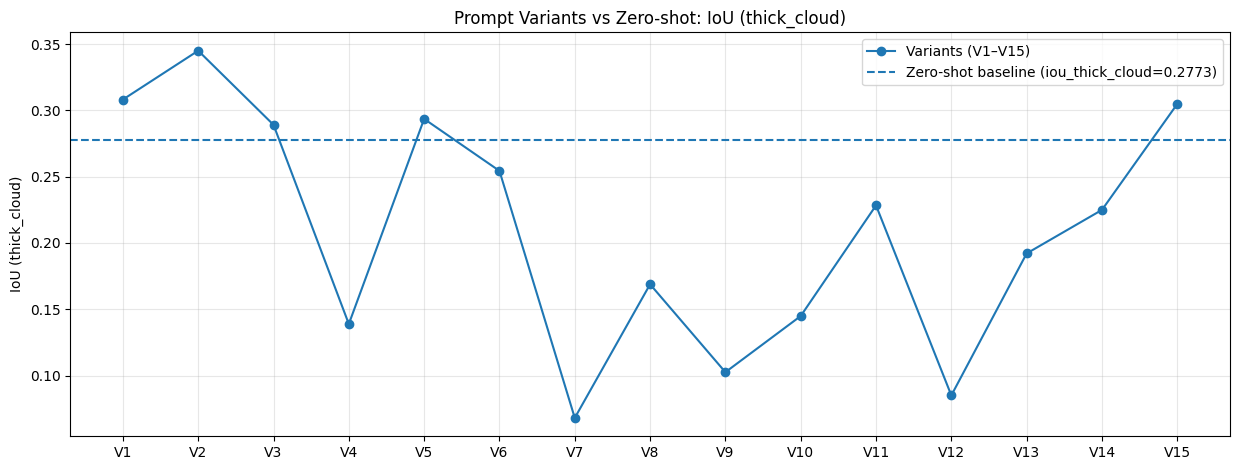

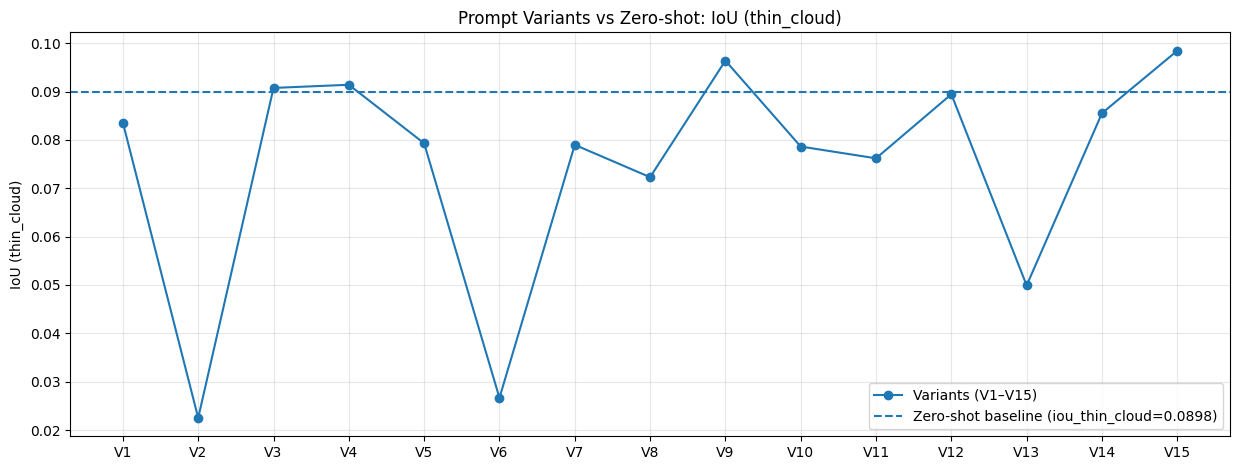

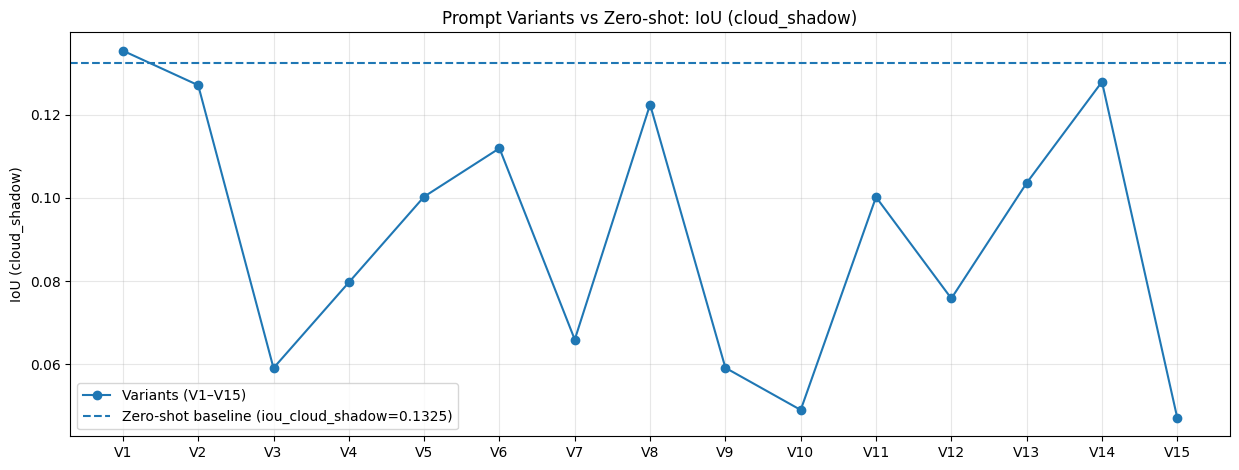

In [ ]:
plot_variants_vs_zs("iou_clear", "Prompt Variants vs Zero-shot: IoU (clear)", "IoU (clear)")
plot_variants_vs_zs("iou_thick_cloud", "Prompt Variants vs Zero-shot: IoU (thick_cloud)", "IoU (thick_cloud)")
plot_variants_vs_zs("iou_thin_cloud", "Prompt Variants vs Zero-shot: IoU (thin_cloud)", "IoU (thin_cloud)")
plot_variants_vs_zs("iou_cloud_shadow", "Prompt Variants vs Zero-shot: IoU (cloud_shadow)", "IoU (cloud_shadow)")


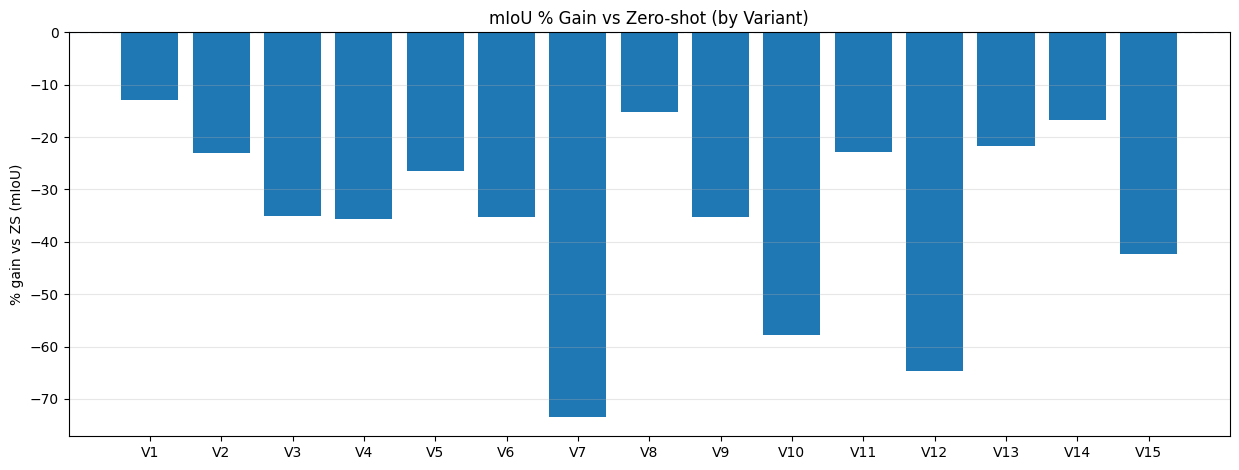

In [ ]:
x_labels = variant_df["variant"].tolist()
g = variant_df["miou_gain_pct"].astype(float).tolist()

plt.figure(figsize=(12.5, 4.8))
plt.bar(range(len(x_labels)), g)
plt.axhline(0.0, linestyle="--")
plt.xticks(range(len(x_labels)), x_labels)
plt.ylabel("% gain vs ZS (mIoU)")
plt.title("mIoU % Gain vs Zero-shot (by Variant)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


#### Prompt Sweep

THICK_CLOUD_VARIANTS = [
  "white cloud",
  "bright white cloud",
  "white opaque cloud",
  "bright cloud",
  "opaque cloud",
  "white",
  "cloud",
  "overhead cloud",
  "bright white",
  "thick cloud",
  "white dense cloud",
  "cloud overhead",
  "bright opaque cloud",
  "white solid cloud",
  "brightest cloud",
]

THIN_CLOUD_VARIANTS = [
  "thin cloud",
  "wispy cloud",
  "cloud layer",
  "translucent cloud",
  "semi-transparent cloud",
  "cloud with ground visible",
  "faded cloud",
  "soft cloud",
  "hazy cloud",
  "light cloud",
  "cloud veil",
  "partial cloud",
  "delicate cloud",
  "subtle cloud",
  "cloud layer with texture",
]

CLEAR_VARIANTS = [
  "ground",
  "earth",
  "surface",
  "land",
  "terrain",
  "colored ground",
  "ground below",
  "visible ground",
  "earth surface",
  "open ground",
  "clear ground",
  "ground below sky",
  "landscape",
  "exposed ground",
  "bright ground",
]

SHADOW_VARIANTS = [
  "shadow",
  "dark shadow",
  "shadow on ground",
  "shadow below",
  "dark area",
  "shade",
  "dark patch",
  "sharp shadow",
  "shadow with edges",
  "ground shadow",
  "cloud shadow",
  "dark region",
  "shadow beneath cloud",
  "darkest area",
  "shadow line",
]